In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import mne

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [10]:
task = 'Active'
file_path = f'Fit_{task}_late'
os.makedirs(file_path, exist_ok=True)
    
# for part in tqdm(range(20)):
part = 18

# Load data
data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
epochs_file = cwd.parents[0] / data_ref

# Load metadata
epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
audibility = epochs.metadata['audibility'].to_numpy()[:-47]
snr = epochs.metadata['snr'].to_numpy()[:-47]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=False)


/tmp/ipykernel_3307/3439923105.py:13: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)


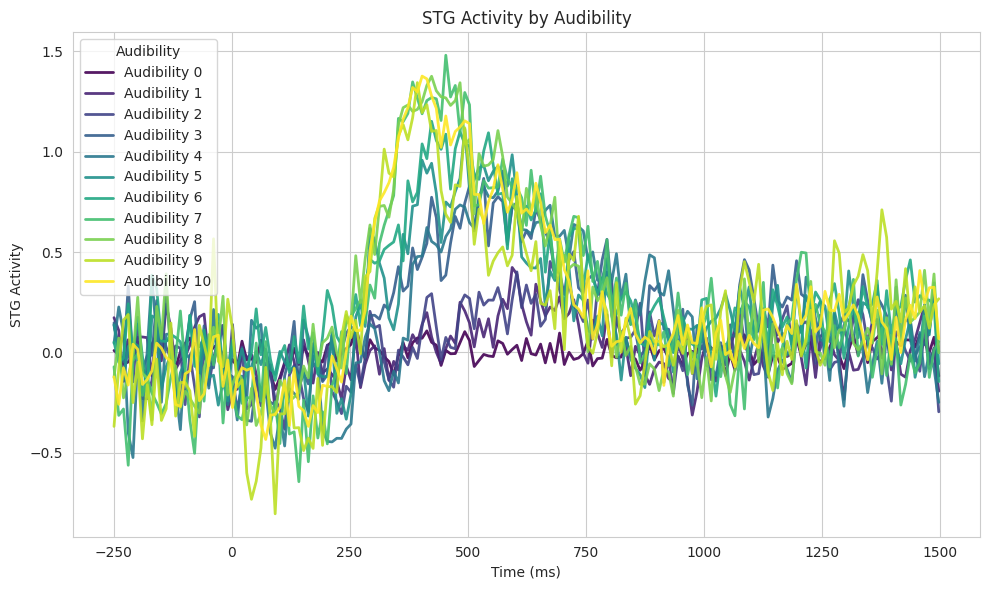

In [15]:
times = np.linspace(-500, 2000, 250)

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
unique_aud = np.unique(audibility)
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(unique_aud)))
for i, aud in enumerate(unique_aud):
    idx = audibility == aud
    plt.plot(times[25:200], state_train[idx].mean(axis=0)[25:200], label=f'Audibility {aud}', color=colors[i], linewidth=2, alpha=0.9)
plt.xlabel('Time (ms)')
plt.ylabel('STG Activity')
plt.title('STG Activity by Audibility')
plt.legend(title='Audibility')
plt.tight_layout()
plt.show()

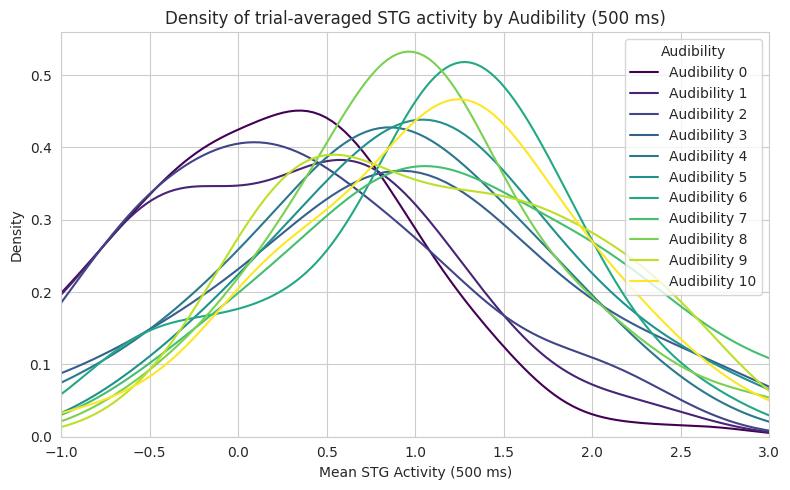

In [38]:
# KDE densities of trial-averaged STG activity between 300 and 500 ms (indexes 80:100)

plt.figure(figsize=(8, 5))
sns.set_style('whitegrid')
unique_aud = np.unique(audibility)
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(unique_aud)))

for i, aud in enumerate(unique_aud):
    idx = audibility == aud
    trial_means = state_train[idx][:, 99:100].mean(axis=1)
    if trial_means.size > 1:
        sns.kdeplot(trial_means, label=f'Audibility {aud}', color=colors[i], fill=False, alpha=1)
    else:
        sns.rugplot(trial_means, color=colors[i])

plt.xlabel('Mean STG Activity (500 ms)')
plt.ylabel('Density')
plt.title('Density of trial-averaged STG activity by Audibility (500 ms)')
plt.xlim(-1, 3)
plt.legend(title='Audibility')
plt.tight_layout()
plt.show()

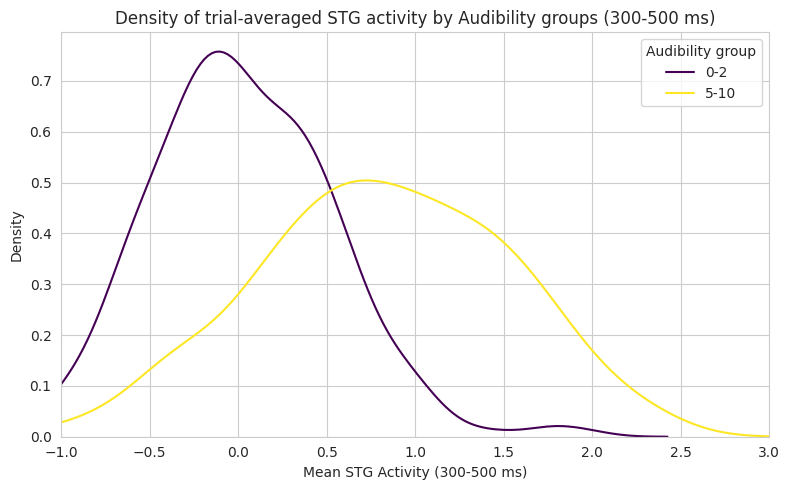

In [39]:
# KDE densities grouped by audibility ranges (300-500 ms)
window = slice(80, 100)
groups = {
    '0-2': [0, 1, 2],
    '5-10': [3, 4, 5, 6, 7, 8, 9, 10]
}

plt.figure(figsize=(8, 5))
sns.set_style('whitegrid')
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(groups)))

for i, (label, gvals) in enumerate(groups.items()):
    idx = np.isin(audibility, gvals)
    trial_means = state_train[idx][:, window].mean(axis=1)
    if trial_means.size > 1:
        sns.kdeplot(trial_means, label=label, color=colors[i], fill=False, alpha=1)
    else:
        sns.rugplot(trial_means, color=colors[i])

plt.xlabel('Mean STG Activity (300-500 ms)')
plt.ylabel('Density')
plt.title('Density of trial-averaged STG activity by Audibility groups (300-500 ms)')
plt.xlim(-1, 3)
plt.legend(title='Audibility group')
plt.tight_layout()
plt.show()

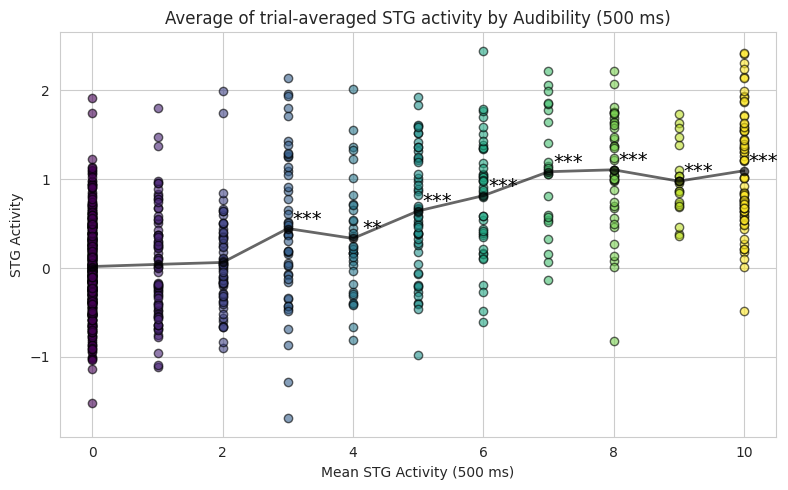

In [55]:
from scipy import stats

plt.figure(figsize=(8, 5))
unique_aud = np.unique(audibility)
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(unique_aud)))

# helper to convert p-value to star string
def p_to_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for i, aud in enumerate(unique_aud):
    idx = audibility == aud
    trial_means = state_train[idx][:, 80:100].mean(axis=1)
    # Rain plot of individual trial means indexed by audibility
    plt.scatter(aud*np.ones_like(trial_means), trial_means, color=colors[i], alpha=0.6, edgecolor='k')

# plot averages for each audibility level and connect with lines
plt.plot(unique_aud, [state_train[audibility == aud][:, 80:100].mean() for aud in unique_aud], color='k', alpha=0.6, marker='o', linestyle='-', linewidth=2)

for aud, mean_y in zip(unique_aud, means_list):
    idx = audibility == aud
    sample = state_train[idx][:, window].mean(axis=1)
    n = np.sum(~np.isnan(sample))
    stars = ''
    if n > 1:
        tstat, pval = stats.ttest_1samp(sample, 0.0, nan_policy='omit')
        stars = p_to_stars(pval) if (pval is not None) else ''
    if stars:
        plt.text(aud+0.3, mean_y, stars, ha='center', va='bottom', fontsize=14, color='k')

plt.xlabel('Mean STG Activity (500 ms)')
plt.ylabel('STG Activity')
plt.title('Average of trial-averaged STG activity by Audibility (500 ms)')
plt.tight_layout()
plt.show()

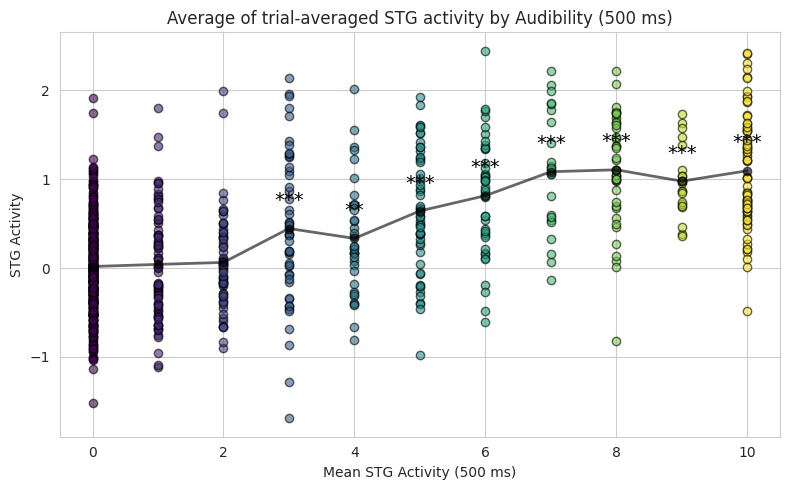

In [ ]:
plt.figure(figsize=(8, 5))
# window for 300-500 ms (indexes)
window = slice(80, 100)
unique_aud = np.unique(audibility)
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(unique_aud)))

# compute global range for offsetting significance stars
global_means = state_train[:, window].mean(axis=1)
gmin, gmax = np.nanmin(global_means), np.nanmax(global_means)
yrange = gmax - gmin if (gmax - gmin) != 0 else 1.0
offset = 0.05 * yrange



# try importing scipy.stats for the one-sample t-test
try:
    from scipy import stats
    _have_scipy = True
except Exception:
    _have_scipy = False

for i, aud in enumerate(unique_aud):
    idx = audibility == aud
    trial_means = state_train[idx][:, window].mean(axis=1)
    # Rain plot of individual trial means indexed by audibility
    plt.scatter(aud * np.ones_like(trial_means), trial_means, color=colors[i], alpha=0.6, edgecolor='k')

# plot averages for each audibility level and connect with lines
means_list = [state_train[audibility == aud][:, window].mean() for aud in unique_aud]
plt.plot(unique_aud, means_list, color='k', alpha=0.6, marker='o', linestyle='-', linewidth=2)

# annotate significance stars above each mean (if scipy available)
if _have_scipy:
    for aud, mean_y in zip(unique_aud, means_list):
        idx = audibility == aud
        sample = state_train[idx][:, window].mean(axis=1)
        n = np.sum(~np.isnan(sample))
        stars = ''
        if n > 1:
            tstat, pval = stats.ttest_1samp(sample, 0.0, nan_policy='omit')
            stars = p_to_stars(pval) if (pval is not None) else ''
        # place the stars slightly above the mean
        if stars:
            plt.text(aud, mean_y + offset, stars, ha='center', va='bottom', fontsize=14, color='k')
else:
    print('scipy not available: skipping significance tests')

plt.xlabel('Mean STG Activity (500 ms)')
plt.ylabel('STG Activity')
plt.title('Average of trial-averaged STG activity by Audibility (500 ms)')
plt.tight_layout()
plt.show()